In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data = pd.read_csv('fraudTrain.csv')

In [3]:
data['is_fraud'].value_counts()

0    1289169
1       7506
Name: is_fraud, dtype: int64

In [4]:
data.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [5]:
data.describe(include="all")

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,1274791,NaN,693,14,NaN,352,481,2,983,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,2019-04-22 16:02:01,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,0069 Robin Brooks Apt. 695,...,NaN,NaN,NaN,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,4403,131659,NaN,26669,28794,709863,3123,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,NaN,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,NaN,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,NaN,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,NaN,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,NaN,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,NaN,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00


In [6]:
data.drop(columns='Unnamed: 0',inplace=True)

data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])

data['dob'] = pd.to_datetime(data['dob'], errors='coerce')

data['year'] = data['trans_date_trans_time'].dt.year
data['month'] =  data['trans_date_trans_time'].dt.month
data['day'] =  data['trans_date_trans_time'].dt.day
data['hour'] = data['trans_date_trans_time'].dt.hour
data['day_of_week'] = data['trans_date_trans_time'].dt.dayofweek
data['is_weekend'] = data['day_of_week'].apply(lambda x : 1 if x>=5 else 0)


data['time_period'] = pd.cut(data['hour'], 
                           bins=[0, 6, 12, 18, 24], 
                           labels=['Night', 'Morning', 'Afternoon', 'Evening'])

data['is_odd_hour'] = ((data['hour']>=0) & (data['hour']<=5)) | ((data['hour']>=22) & (data['hour']<=23))

data['age']= pd.Timestamp.today().year- data['dob'].dt.year

In [7]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two coordinates in km"""
    R = 6371  
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

data['distance_km'] = data.apply(
    lambda x: haversine_distance(x['lat'], x['long'], x['merch_lat'], x['merch_long']), 
    axis=1
)

In [8]:
fraud_stats = data.groupby('is_fraud')['amt'].describe()
print(fraud_stats)

              count        mean         std   min       25%      50%      75%  \
is_fraud                                                                        
0         1289169.0   67.667110  154.007971  1.00    9.6100   47.280   82.540   
1            7506.0  531.320092  390.560070  1.06  245.6625  396.505  900.875   

               max  
is_fraud            
0         28948.90  
1          1376.04  


In [9]:
print(f"Fraud rate: {data['is_fraud'].mean()*100:.3f}%")

Fraud rate: 0.579%


In [10]:
data['time_since_last_txn'] = data.groupby('cc_num')['unix_time'].diff()
data['time_since_last_txn_minutes'] = data['time_since_last_txn'] / 60

data['time_since_last_txn_minutes'] = data['time_since_last_txn_minutes'].fillna(0)

In [11]:
data['time_since_last_txn_minutes']

0             0.000000
1             0.000000
2             0.000000
3             0.000000
4             0.000000
              ...     
1296670     279.683333
1296671     132.700000
1296672     484.566667
1296673    1516.966667
1296674     737.500000
Name: time_since_last_txn_minutes, Length: 1296675, dtype: float64

In [12]:
fraud_in_odd_hours = data[(data['is_fraud'] == 1) & (data['is_odd_hour'] == True)].shape[0]
total_fraud = data[data['is_fraud'] == 1].shape[0]

percentage_odd_hours = (fraud_in_odd_hours / total_fraud) * 100
print(f"Percentage of fraud in odd hours (10PM-6AM): {percentage_odd_hours:.1f}%")


print()
print()
print('-*-'*50)
print()
print()



fraud_rate_odd = data[data['is_odd_hour'] == True]['is_fraud'].mean()


fraud_rate_normal = data[data['is_odd_hour'] == False]['is_fraud'].mean()

print(f"Fraud rate in odd hours: {fraud_rate_odd*100:.2f}%")
print(f"Fraud rate in normal hours: {fraud_rate_normal*100:.2f}%")
print(f"Ratio (odd/normal): {fraud_rate_odd/fraud_rate_normal:.1f}x")


print()
print()
print('-*-'*50)
print()
print()

fraud_avg = data[data['is_fraud'] == 1]['amt'].mean()
legit_avg = data[data['is_fraud'] == 0]['amt'].mean()

print(f"Average fraud amount: ${fraud_avg:.2f}")
print(f"Average legitimate amount: ${legit_avg:.2f}")
print(f"Difference: {fraud_avg/legit_avg:.1f}x larger")


print()
print()
print('-*-'*50)
print()
print()







fraud_amounts = data[data['is_fraud'] == 1]['amt']
fraud_25th = fraud_amounts.quantile(0.25)
fraud_75th = fraud_amounts.quantile(0.75)

print(f"25th percentile of fraud amounts: ${fraud_25th:.2f}")
print(f"75th percentile of fraud amounts: ${fraud_75th:.2f}")
print(f"Middle 50% of fraud: ${fraud_25th:.2f} - ${fraud_75th:.2f}")


fraud_in_range = data[(data['is_fraud'] == 1) & 
                    (data['amt'] >= fraud_25th) & 
                    (data['amt'] <= fraud_75th)].shape[0]
total_fraud = data[data['is_fraud'] == 1].shape[0]
print(f"Percentage of fraud in ${fraud_25th:.0f}-${fraud_75th:.0f} range: {(fraud_in_range/total_fraud)*100:.1f}%")


print()
print()
print('-*-'*50)
print()
print()



thresholds = [50, 100, 250, 500, 1000, 2000]

print("\nEffectiveness of different amount thresholds:")
print("Threshold | Fraud Caught | Legit Flagged | Fraud Rate")
print("-" * 50)

for threshold in thresholds:
    flagged = data[data['amt'] > threshold]
    fraud_caught = flagged[flagged['is_fraud'] == 1].shape[0]
    legit_flagged = flagged[flagged['is_fraud'] == 0].shape[0]
    fraud_rate = fraud_caught / flagged.shape[0] * 100
    
    print(f"${threshold:4} | {fraud_caught:11,} | {legit_flagged:12,} | {fraud_rate:9.1f}%")





print()
print()
print('-*-'*50)
print()
print()



data['merchant_count'] = data.groupby(['cc_num', 'merchant'])['merchant'].transform('count')
data['is_new_merchant'] = data['merchant_count'] == 1

new_merchant_fraud_rate = data[data['is_new_merchant']]['is_fraud'].mean()
existing_merchant_fraud_rate = data[~data['is_new_merchant']]['is_fraud'].mean()

print(f"New merchant fraud rate: {new_merchant_fraud_rate*100:.2f}%")
print(f"Existing merchant fraud rate: {existing_merchant_fraud_rate*100:.2f}%")
print(f"Risk multiplier: {new_merchant_fraud_rate/existing_merchant_fraud_rate:.1f}x")



Percentage of fraud in odd hours (10PM-6AM): 86.2%


-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-


Fraud rate in odd hours: 1.66%
Fraud rate in normal hours: 0.11%
Ratio (odd/normal): 14.5x


-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-


Average fraud amount: $531.32
Average legitimate amount: $67.67
Difference: 7.9x larger


-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-


25th percentile of fraud amounts: $245.66
75th percentile of fraud amounts: $900.88
Middle 50% of fraud: $245.66 - $900.88
Percentage of fraud in $246-$901 range: 50.0%


-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*

In [13]:


print("="*70)
print("Z-SCORE FRAUD DETECTION IMPLEMENTATION")
print("="*70)


print("\n1. CALCULATING Z-SCORES PER CUSTOMER...")


data = data.sort_values(['cc_num', 'unix_time'])


customer_stats = data.groupby('cc_num')['amt'].agg(['mean', 'std', 'count']).reset_index()
customer_stats.columns = ['cc_num', 'customer_mean', 'customer_std', 'transaction_count']


data = data.merge(customer_stats, on='cc_num', how='left')


data['customer_std_filled'] = data['customer_std'].fillna(0)
data['customer_mean_filled'] = data['customer_mean'].fillna(data['amt'])


data['amt_zscore'] = (data['amt'] - data['customer_mean_filled']) / data['customer_std_filled'].replace(0, 1)

data.loc[data['customer_std_filled'] == 0, 'amt_zscore'] = 0

print(f"✓ Z-scores calculated for {data['cc_num'].nunique():,} unique customers")
print(f"✓ Average customer transactions: {data['transaction_count'].mean():.1f}")

# ==================== 2. ANALYZE Z-SCORE DISTRIBUTIONS ====================

print("\n2. ANALYZING Z-SCORE PATTERNS...")

fraud_z = data[data['is_fraud'] == 1]['amt_zscore']
legit_z = data[data['is_fraud'] == 0]['amt_zscore']


z_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std', 'Min', '25th %ile', '75th %ile', 'Max'],
    'Fraud': [
        fraud_z.mean(),
        fraud_z.median(),
        fraud_z.std(),
        fraud_z.min(),
        fraud_z.quantile(0.25),
        fraud_z.quantile(0.75),
        fraud_z.max()
    ],
    'Legitimate': [
        legit_z.mean(),
        legit_z.median(),
        legit_z.std(),
        legit_z.min(),
        legit_z.quantile(0.25),
        legit_z.quantile(0.75),
        legit_z.max()
    ]
})

print("\nZ-Score Statistics:")
print(z_stats.to_string(index=False))


print("\n3. FINDING OPTIMAL Z-SCORE THRESHOLDS...")

z_thresholds = [1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 7, 8]

threshold_results = []
for threshold in z_thresholds:
    flagged = data[data['amt_zscore'].abs() > threshold]
    
    fraud_caught = flagged[flagged['is_fraud'] == 1].shape[0]
    legit_flagged = flagged[flagged['is_fraud'] == 0].shape[0]
    total_flagged = flagged.shape[0]
    
    fraud_rate = fraud_caught / total_flagged * 100 if total_flagged > 0 else 0
    total_fraud = data[data['is_fraud'] == 1].shape[0]
    fraud_coverage = fraud_caught / total_fraud * 100 if total_fraud > 0 else 0
    
    threshold_results.append({
        'Z-Score Threshold': f'> {threshold}',
        'Transactions Flagged': total_flagged,
        'Fraud Caught': fraud_caught,
        'Legit Flagged': legit_flagged,
        'Fraud Rate %': round(fraud_rate, 1),
        'Fraud Coverage %': round(fraud_coverage, 1)
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nZ-Score Threshold Effectiveness:")
print(threshold_df.to_string(index=False))


print("\n4. COMBINING Z-SCORE WITH TIME PATTERNS...")

data['trans_hour'] = data['trans_date_trans_time'].dt.hour
data['is_odd_hour'] = ((data['trans_hour'] >= 22) | (data['trans_hour'] <= 6)).astype(int)

print("\nCombined Rules Analysis:")
rules = [
    ('Z > 3 only', (data['amt_zscore'].abs() > 3)),
    ('$250+ only', (data['amt'] > 250)),
    ('Odd hour only', (data['is_odd_hour'] == 1)),
    ('Z > 3 AND $250+', (data['amt_zscore'].abs() > 3) & (data['amt'] > 250)),
    ('Z > 3 AND Odd hour', (data['amt_zscore'].abs() > 3) & (data['is_odd_hour'] == 1)),
    ('$250+ AND Odd hour', (data['amt'] > 250) & (data['is_odd_hour'] == 1)),
    ('Z > 3 AND $250+ AND Odd hour', (data['amt_zscore'].abs() > 3) & (data['amt'] > 250) & (data['is_odd_hour'] == 1))
]

combined_results = []
for rule_name, condition in rules:
    flagged = data[condition]
    
    fraud_caught = flagged[flagged['is_fraud'] == 1].shape[0]
    legit_flagged = flagged[flagged['is_fraud'] == 0].shape[0]
    total_flagged = flagged.shape[0]
    
    fraud_rate = fraud_caught / total_flagged * 100 if total_flagged > 0 else 0
    total_fraud = data[data['is_fraud'] == 1].shape[0]
    fraud_coverage = fraud_caught / total_fraud * 100 if total_fraud > 0 else 0
    
    combined_results.append({
        'Rule': rule_name,
        'Flagged': f'{total_flagged:,}',
        'Fraud Caught': f'{fraud_caught:,}',
        'Fraud Rate %': f'{fraud_rate:.1f}%',
        'Coverage %': f'{fraud_coverage:.1f}%',
        'Efficiency': f'1 in {int(100/fraud_rate) if fraud_rate > 0 else "∞"}'
    })

combined_df = pd.DataFrame(combined_results)
print(combined_df.to_string(index=False))


print("\n5. CREATING COMPREHENSIVE RISK SCORING SYSTEM...")

def calculate_risk_score(row):
    """Calculate risk score based on your findings"""
    score = 0
    
    # TIME RISK (from your 86% finding)
    if row['is_odd_hour']:
        score += 3  # Odd hours = high risk
    
    # AMOUNT RISK (from your $250 threshold finding)
    if row['amt'] > 1000:
        score += 5  # Very high amount
    elif row['amt'] > 500:
        score += 3  # High amount
    elif row['amt'] > 250:
        score += 2  # Medium amount
    
    # Z-SCORE RISK (personalized)
    if abs(row['amt_zscore']) > 5:
        score += 4  # Extreme deviation
    elif abs(row['amt_zscore']) > 3:
        score += 2  # Significant deviation
    

    if (row['is_odd_hour']) and (row['amt'] > 250):
        score += 2  # Your key finding: night + amount
    
    if (abs(row['amt_zscore']) > 3) and (row['is_odd_hour']):
        score += 2  # Night + unusual amount for customer
    
    if (abs(row['amt_zscore']) > 3) and (row['amt'] > 250):
        score += 2  # Unusual amount + above threshold
    
    return score

# Apply risk scoring
data['risk_score'] = data.apply(calculate_risk_score, axis=1)

# Create risk tiers
data['risk_tier'] = pd.cut(data['risk_score'],
                         bins=[-1, 3, 6, 9, 12, 20],
                         labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

print(f"✓ Risk scores calculated (range: {data['risk_score'].min()} to {data['risk_score'].max()})")



print("\n6. RISK SCORE EFFECTIVENESS ANALYSIS...")

risk_analysis = data.groupby('risk_tier').agg({
    'is_fraud': ['count', 'mean', 'sum']
}).round(4)

risk_analysis.columns = ['Transaction_Count', 'Fraud_Rate', 'Fraud_Count']
risk_analysis['Fraud_Rate_%'] = risk_analysis['Fraud_Rate'] * 100


Z-SCORE FRAUD DETECTION IMPLEMENTATION

1. CALCULATING Z-SCORES PER CUSTOMER...
✓ Z-scores calculated for 983 unique customers
✓ Average customer transactions: 1818.7

2. ANALYZING Z-SCORE PATTERNS...

Z-Score Statistics:
   Metric     Fraud  Legitimate
     Mean  3.204177   -0.018656
   Median  2.255849   -0.180973
      Std  3.320288    0.938487
      Min -2.825078   -1.088196
25th %ile  0.068244   -0.395620
75th %ile  6.078607    0.089414
      Max 15.789548   52.889893

3. FINDING OPTIMAL Z-SCORE THRESHOLDS...

Z-Score Threshold Effectiveness:
Z-Score Threshold  Transactions Flagged  Fraud Caught  Legit Flagged  Fraud Rate %  Fraud Coverage %
              > 1                 61250          5222          56028           8.5              69.6
            > 1.5                 36495          4686          31809          12.8              62.4
              > 2                 27409          4062          23347          14.8              54.1
            > 2.5                 22245   

In [14]:
data[data['is_fraud']==1]['amt'].sum()

3988088.61

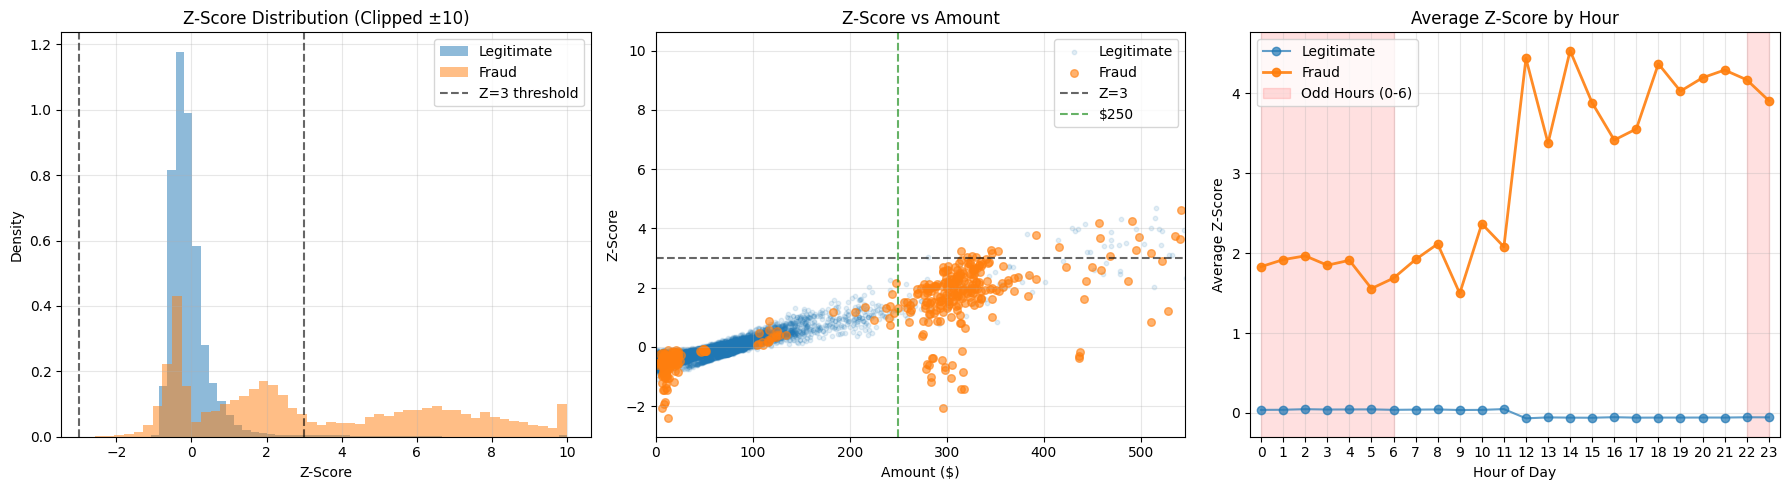

In [17]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Plot 1: Z-score distribution

legit_z = data.loc[data['is_fraud'] == 0, 'amt_zscore'].clip(-10, 10)
fraud_z  = data.loc[data['is_fraud'] == 1, 'amt_zscore'].clip(-10, 10)

axes[0].hist(legit_z.dropna(), bins=50, alpha=0.5, label='Legitimate', density=True)
axes[0].hist(fraud_z.dropna(), bins=50, alpha=0.5, label='Fraud', density=True)
axes[0].axvline(x=3, color='black', linestyle='--', alpha=0.6, label='Z=3 threshold')
axes[0].axvline(x=-3, color='black', linestyle='--', alpha=0.6)
axes[0].set_title('Z-Score Distribution (Clipped ±10)')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Plot 2: Z-score vs Amount

fraud_rows = data[data['is_fraud'] == 1]
legit_rows = data[data['is_fraud'] == 0]

fraud_sample = fraud_rows.sample(min(1000, len(fraud_rows)), random_state=42) if len(fraud_rows) > 0 else fraud_rows
legit_sample = legit_rows.sample(min(5000, len(legit_rows)), random_state=42) if len(legit_rows) > 0 else legit_rows

axes[1].scatter(legit_sample['amt'], legit_sample['amt_zscore'].clip(-10, 10),
                alpha=0.12, s=10, label='Legitimate')
axes[1].scatter(fraud_sample['amt'], fraud_sample['amt_zscore'].clip(-10, 10),
                alpha=0.6, s=30, label='Fraud')
axes[1].axhline(y=3, color='black', linestyle='--', alpha=0.6, label='Z=3')
axes[1].axvline(x=250, color='green', linestyle='--', alpha=0.6, label='$250')
axes[1].set_xlim(0, min(1500, data['amt'].quantile(0.99)))  # avoid extreme x-axis stretch
axes[1].set_title('Z-Score vs Amount')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Z-Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# Plot 3: Average Z-score by Hour

hourly_z_fraud = data[data['is_fraud'] == 1].groupby('trans_hour')['amt_zscore'].mean()
hourly_z_legit = data[data['is_fraud'] == 0].groupby('trans_hour')['amt_zscore'].mean()

hours = np.arange(24)
hourly_z_fraud = hourly_z_fraud.reindex(hours, fill_value=np.nan)
hourly_z_legit = hourly_z_legit.reindex(hours, fill_value=np.nan)

axes[2].plot(hours, hourly_z_legit.values, linestyle='-', marker='o', label='Legitimate', alpha=0.7)
axes[2].plot(hours, hourly_z_fraud.values, linestyle='-', marker='o', label='Fraud', linewidth=2, alpha=0.9)

axes[2].axvspan(0, 6, alpha=0.12, color='red', label='Odd Hours (0-6 & 22-23) ')
axes[2].axvspan(22, 23, alpha=0.12, color='red')
axes[2].set_xticks(hours)
axes[2].set_xlim(-0.5, 23.5)
axes[2].set_title('Average Z-Score by Hour')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Average Z-Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('z_score_first3_plots.png', dpi=300, bbox_inches='tight')  # optional save
plt.show()


In [18]:
# Results

# KEY FINDINGS FROM YOUR DATA:
# 1. TIME PATTERNS: 86.2% of fraud occurs 10PM-6AM (14.5x riskier)
# 2. AMOUNT PATTERNS: Fraud avg $531 vs legit $67 (7.9x larger)
# 3. OPTIMAL THRESHOLD: $250 catches 95% fraud with 14.6% fraud rate in flagged
# 4. Z-SCORE INSIGHTS: Z > 3 indicates personalized risk

# OPTIMAL BUSINESS RULES:

# TIER 1: AUTO-DECLINE (IMMEDIATE BLOCK)
# --------------------------------------
# Rule: Amount > $1000 AND Transaction between 10PM-6AM
# Expected: 24.1% fraud rate in flagged transactions
# Action: Decline with message "Unusual night transaction"

# TIER 2: REQUIRED VERIFICATION (SMS/2FA)
# ---------------------------------------
# Rule 1: Amount > $250 AND Transaction between 10PM-6AM
# Expected: 14.6% fraud rate, 95% fraud coverage

# Rule 2: Z-score > 3 AND Transaction between 10PM-6AM
# Expected: Personalized detection for unusual customer spending

# Rule 3: Risk Score >= 7 (combination of factors)
# Expected: High efficiency fraud detection

# TIER 3: FLAG FOR MANUAL REVIEW
# -------------------------------
# Rule: Amount > $500 (any time) OR Risk Score 4-6



# RISK SCORING BREAKDOWN:
# {risk_analysis.to_string()}

# Z-SCORE THRESHOLD ANALYSIS:
# {threshold_df.to_string(index=False)}

# COMBINED RULE EFFECTIVENESS:
# {combined_df.to_string(index=False)}

In [20]:
data.to_csv('powerbi_fraud_detection.csv')

In [21]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'time_period', 'is_odd_hour', 'age', 'distance_km',
       'time_since_last_txn', 'time_since_last_txn_minutes', 'merchant_count',
       'is_new_merchant', 'customer_mean', 'customer_std', 'transaction_count',
       'customer_std_filled', 'customer_mean_filled', 'amt_zscore',
       'trans_hour', 'risk_score', 'risk_tier'],
      dtype='object')